In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv('C:/Users/Priya/Desktop/Atlantic_Playlist_Analysis/data/Atlantic_United_States.csv')

In [3]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,Kill Bill,SZA,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [4]:
df.tail()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
27795,27-11-2025,46,Love Somebody,Morgan Wallen,86,204828,single,1,False,https://i.scdn.co/image/ab67616d0000b2734b8622...
27796,27-11-2025,47,HOT TO GO!,Chappell Roan,88,184841,album,14,False,https://i.scdn.co/image/ab67616d0000b27396fa88...
27797,27-11-2025,48,Sweater Weather,The Neighbourhood,90,240400,album,11,False,https://i.scdn.co/image/ab67616d0000b2738265a7...
27798,27-11-2025,49,Stick Season,Noah Kahan,87,182346,album,14,False,https://i.scdn.co/image/ab67616d0000b2736ee350...
27799,27-11-2025,50,Bed Chem,Sabrina Carpenter,90,171869,album,12,False,https://i.scdn.co/image/ab67616d0000b273fd8d7a...


In [5]:
df.shape

(27800, 10)

In [6]:
df.columns

Index(['date', 'position', 'song', 'artist', 'popularity', 'duration_ms',
       'album_type', 'total_tracks', 'is_explicit', 'album_cover_url'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27800 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB


In [8]:
df.describe()

,position,popularity,duration_ms,total_tracks
count,27800.000000,27800.000000,27800.000000,27800.000000
mean,25.500000,87.665612,198635.820180,12.945000
std,14.431129,10.463848,48057.863668,9.457927
min,1.000000,0.000000,37314.000000,1.000000
25%,13.000000,85.000000,166453.000000,2.000000
50%,25.500000,89.000000,189386.000000,14.000000
75%,38.000000,93.000000,228013.000000,18.000000
max,50.000000,100.000000,740010.000000,119.000000


In [9]:
df.isnull().sum()

date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(10)

In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             27800 non-null  datetime64[ns]
 1   position         27800 non-null  int64         
 2   song             27800 non-null  object        
 3   artist           27800 non-null  object        
 4   popularity       27800 non-null  int64         
 5   duration_ms      27800 non-null  int64         
 6   album_type       27800 non-null  object        
 7   total_tracks     27800 non-null  int64         
 8   is_explicit      27800 non-null  bool          
 9   album_cover_url  27800 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(4), object(4)
memory usage: 1.9+ MB


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df['artist'] = df['artist'].str.strip()

In [15]:
df['song'] = df['song'].str.strip()

In [16]:
df['position'].min(), df['position'].max()

(np.int64(1), np.int64(50))

In [17]:
duplicates = df[df.duplicated(['date','song'], keep=False)]

duplicates

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
8362,2024-11-01,13,Ghostbusters,Various Artists,78,245253,compilation,14,False,https://i.scdn.co/image/ab67616d0000b273aed480...
8375,2024-11-01,26,Ghostbusters,Ray Parker Jr.,75,239133,compilation,14,False,https://i.scdn.co/image/ab67616d0000b273841c8f...
11069,2024-12-25,20,Christmas (Baby Please Come Home),Darlene Love,85,166453,album,15,False,https://i.scdn.co/image/ab67616d0000b2734bd425...
11096,2024-12-25,47,Christmas (Baby Please Come Home),Mariah Carey,88,153240,album,10,False,https://i.scdn.co/image/ab67616d0000b2734246e3...
14351,2025-03-01,2,TEXAS HOLD 'EM,Beyoncé,86,235636,single,3,True,https://i.scdn.co/image/ab67616d0000b2736c1836...
...,...,...,...,...,...,...,...,...,...,...
14442,2025-03-01,43,Bandit,Don Toliver,88,147746,single,1,True,https://i.scdn.co/image/ab67616d0000b273a14990...
14443,2025-03-01,44,Agora Hills,Doja Cat,84,265360,album,15,True,https://i.scdn.co/image/ab67616d0000b273a84003...
14444,2025-03-01,45,Heading South,Zach Bryan,88,171692,single,1,True,https://i.scdn.co/image/ab67616d0000b273f9017b...
14445,2025-03-01,46,FUK SUMN,¥$ & Kanye West & Ty Dolla $ign,88,209577,album,16,True,https://i.scdn.co/image/ab67616d0000b2730a31b4...


In [18]:
df.to_csv("clean_playlist.csv", index=False)

In [19]:
df.nunique()

date               555
position            50
song               943
artist             297
popularity          84
duration_ms        925
album_type           3
total_tracks        35
is_explicit          2
album_cover_url    538
dtype: int64

In [20]:
df.describe(include='all')

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
count,27790,27790.000000,27790,27790,27790.000000,27790.000000,27790,27790.000000,27790,27790
unique,NaN,NaN,943,297,NaN,NaN,3,NaN,2,538
top,NaN,NaN,Something in the Orange,Taylor Swift,NaN,NaN,album,NaN,False,https://i.scdn.co/image/ab67616d0000b273705079...
freq,NaN,NaN,537,2015,NaN,NaN,19735,NaN,14461,1315
mean,2025-02-20 08:28:19.604173824,25.503814,NaN,NaN,87.663584,198643.978409,NaN,12.945448,NaN,NaN
min,2024-05-18 00:00:00,1.000000,NaN,NaN,0.000000,37314.000000,NaN,1.000000,NaN,NaN
25%,2024-10-03 00:00:00,13.000000,NaN,NaN,85.000000,166453.000000,NaN,2.000000,NaN,NaN
50%,2025-02-19 00:00:00,26.000000,NaN,NaN,89.000000,189386.000000,NaN,14.000000,NaN,NaN
75%,2025-07-10 00:00:00,38.000000,NaN,NaN,93.000000,228013.000000,NaN,18.000000,NaN,NaN
max,2025-11-27 00:00:00,50.000000,NaN,NaN,100.000000,740010.000000,NaN,119.000000,NaN,NaN


In [21]:
df["duration_minutes"] = df["duration_ms"] / 60000

In [22]:
df[["duration_ms", "duration_minutes"]].head()

,duration_ms,duration_minutes
0,165671,2.761183
1,163854,2.730900
2,223878,3.731300
3,194563,3.242717
4,153946,2.565767


In [23]:
days_chart = (
    df.groupby("song")["date"]
      .nunique()
      .reset_index(name="days_on_chart")
)

In [24]:
df = df.merge(days_chart, on="song", how="left")

In [25]:
df[["song", "days_on_chart"]].head()

,song,days_on_chart
0,Ella Baila Sola,170
1,Last Night,492
2,All My Life (feat. J. Cole),96
3,un x100to,100
4,Kill Bill,247


In [26]:
avg_rank = (
    df.groupby("song")["position"]
      .mean()
      .reset_index(name="average_rank")
)

df = df.merge(avg_rank, on="song", how="left")

In [27]:
best_rank = (
    df.groupby("song")["position"]
      .min()
      .reset_index(name="best_rank")
)

df = df.merge(best_rank, on="song", how="left")

In [28]:
rank_volatility = (
    df.groupby("song")["position"]
      .std()
      .fillna(0)
      .reset_index(name="rank_volatility")
)

df = df.merge(rank_volatility, on="song", how="left")

In [29]:
df = df.sort_values(["song", "date"])

df["popularity_trend"] = (
    df.groupby("song")["popularity"]
      .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

In [30]:
artist_dom = (
    df.groupby("artist")
      .size()
      .reset_index(name="artist_dominance")
)

df = df.merge(artist_dom, on="artist", how="left")

In [31]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_minutes,days_on_chart,average_rank,best_rank,rank_volatility,popularity_trend,artist_dominance
0,2024-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,0,180381,album,21,False,https://i.scdn.co/image/ab67616d0000b2735cc1de...,3.00635,26,15.5,3,12.130128,0.000000,2015
1,2024-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,84,180381,album,21,False,https://i.scdn.co/image/ab67616d0000b2735cc1de...,3.00635,26,15.5,3,12.130128,42.000000,2015
2,2024-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,86,180381,album,21,False,https://i.scdn.co/image/ab67616d0000b2735cc1de...,3.00635,26,15.5,3,12.130128,56.666667,2015
3,2024-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,88,180381,album,21,False,https://i.scdn.co/image/ab67616d0000b2735cc1de...,3.00635,26,15.5,3,12.130128,64.500000,2015
4,2024-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,89,180381,album,21,False,https://i.scdn.co/image/ab67616d0000b2735cc1de...,3.00635,26,15.5,3,12.130128,69.400000,2015


In [32]:
df.to_csv("playlist_feature_engineered.csv", index=False)

# Daily Rank Distribution

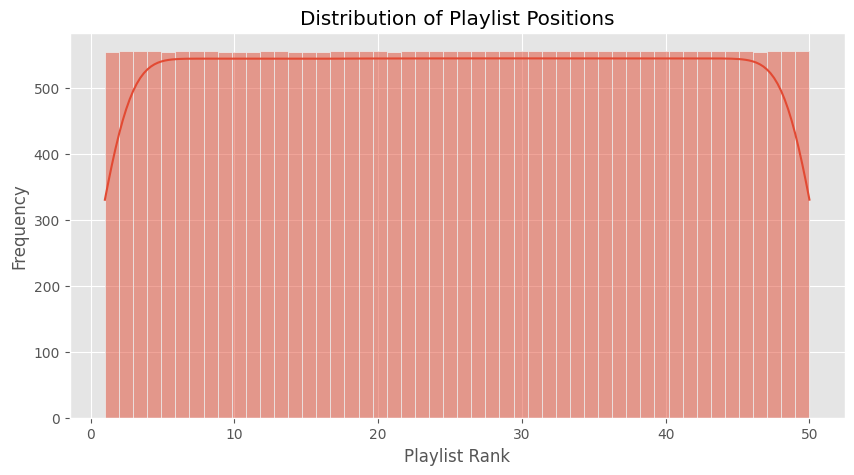

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df['position'], bins=50, kde=True)

plt.title("Distribution of Playlist Positions")
plt.xlabel("Playlist Rank")
plt.ylabel("Frequency")
plt.show()

# Daily Playlist Snapshot

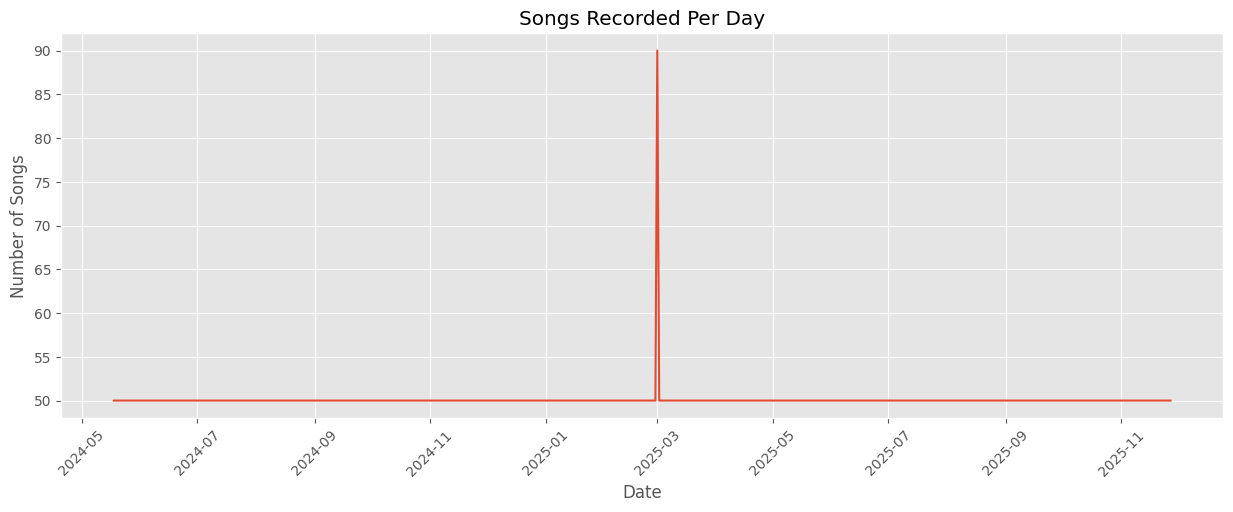

In [34]:
songs_per_day = df.groupby("date").size().reset_index(name="songs")

plt.figure(figsize=(15,5))
plt.plot(songs_per_day["date"], songs_per_day["songs"])

plt.title("Songs Recorded Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)

plt.show()

# Top 10 Songs by Days on Chart

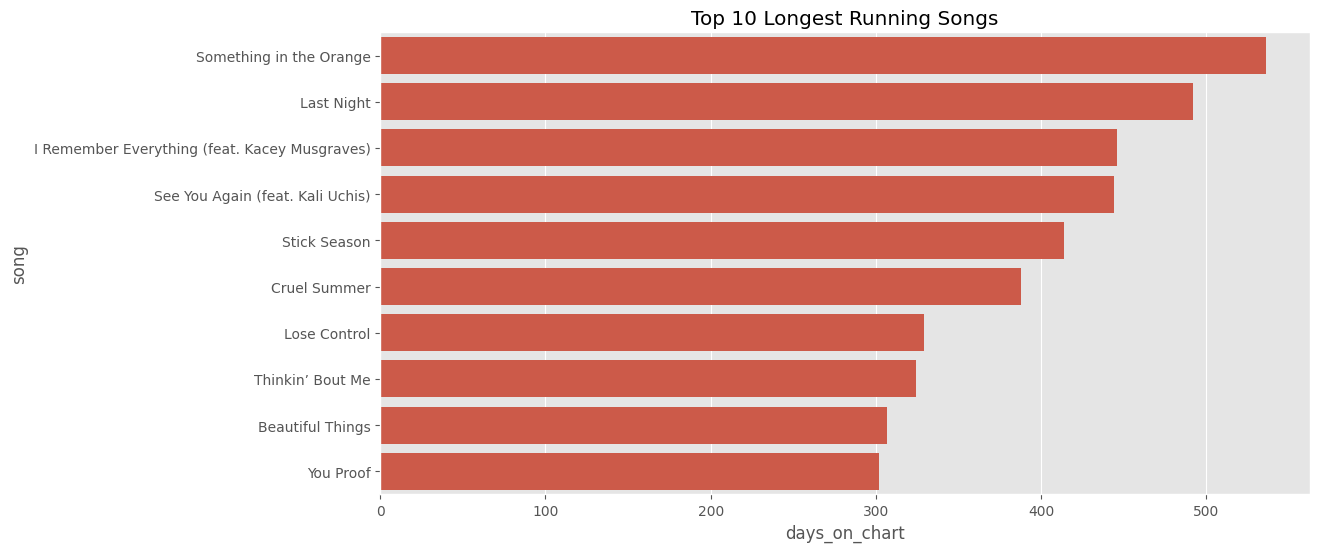

In [35]:
top_days = (
    df[["song","days_on_chart"]]
    .drop_duplicates()
    .sort_values("days_on_chart",ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="days_on_chart",
    y="song",
    data=top_days
)

plt.title("Top 10 Longest Running Songs")

plt.show()

# Best Ranked Songs

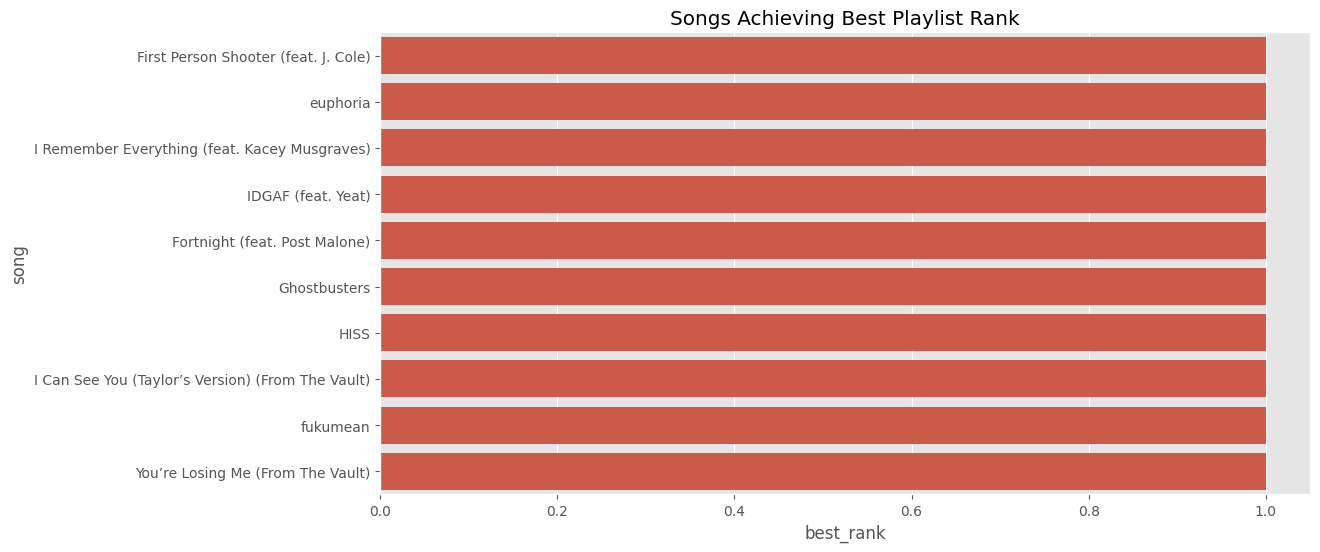

In [36]:
best_rank = (
    df[["song","best_rank"]]
    .drop_duplicates()
    .sort_values("best_rank")
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="best_rank",
    y="song",
    data=best_rank
)

plt.title("Songs Achieving Best Playlist Rank")

plt.show()

# Average Rank of Top Songs

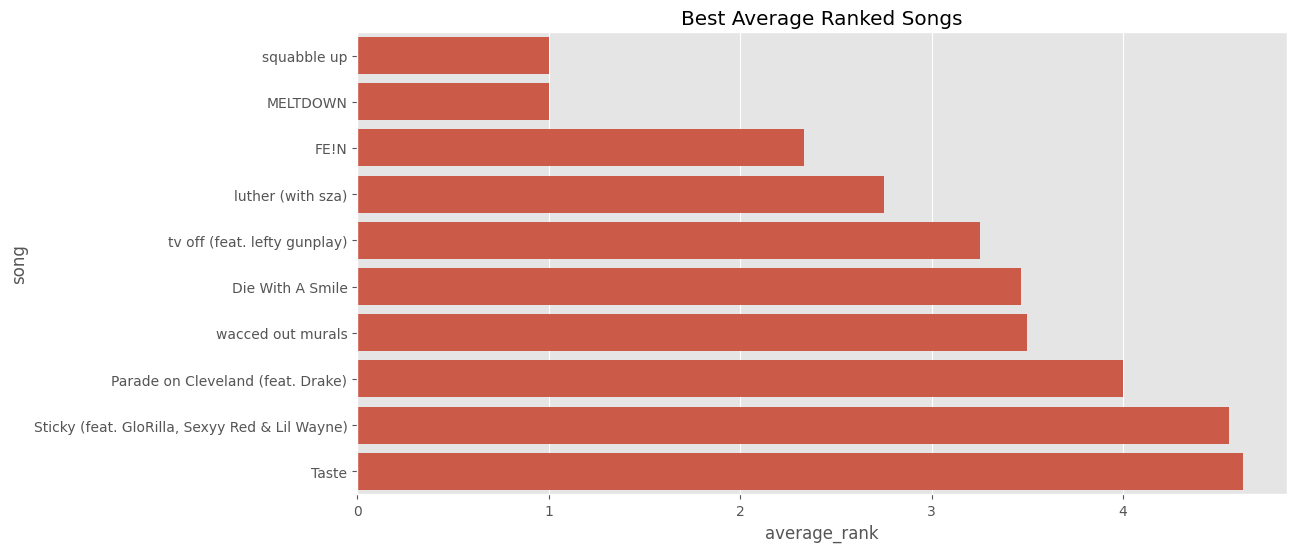

In [37]:
top_avg = (
    df[["song","average_rank"]]
    .drop_duplicates()
    .sort_values("average_rank")
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="average_rank",
    y="song",
    data=top_avg
)

plt.title("Best Average Ranked Songs")

plt.show()

# Rank Volatility Analysis

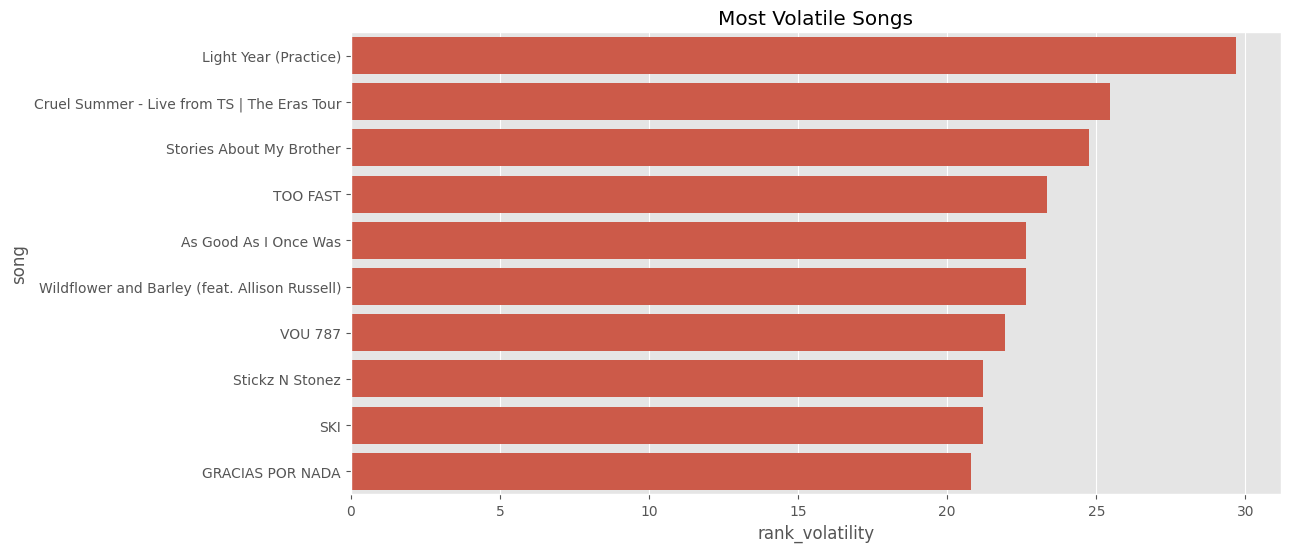

In [38]:
top_volatility = (
    df[["song","rank_volatility"]]
    .drop_duplicates()
    .sort_values("rank_volatility",ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="rank_volatility",
    y="song",
    data=top_volatility
)

plt.title("Most Volatile Songs")

plt.show()

# Popularity Distribution

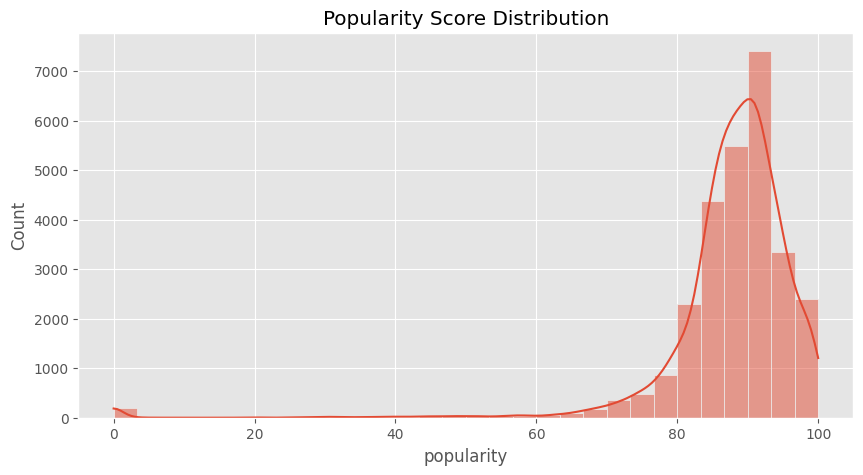

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(df["popularity"], bins=30, kde=True)

plt.title("Popularity Score Distribution")

plt.show()

# Correlation Between Popularity and Rank

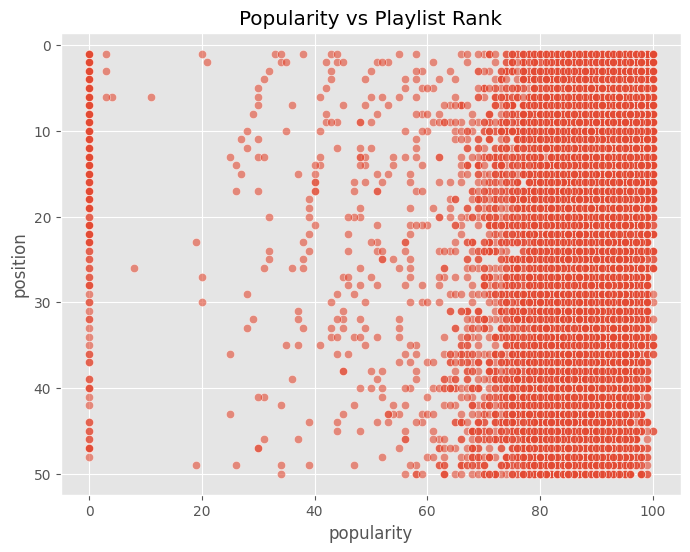

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="popularity",
    y="position",
    data=df,
    alpha=0.6
)

plt.gca().invert_yaxis()

plt.title("Popularity vs Playlist Rank")

plt.show()

# Correlation Matrix

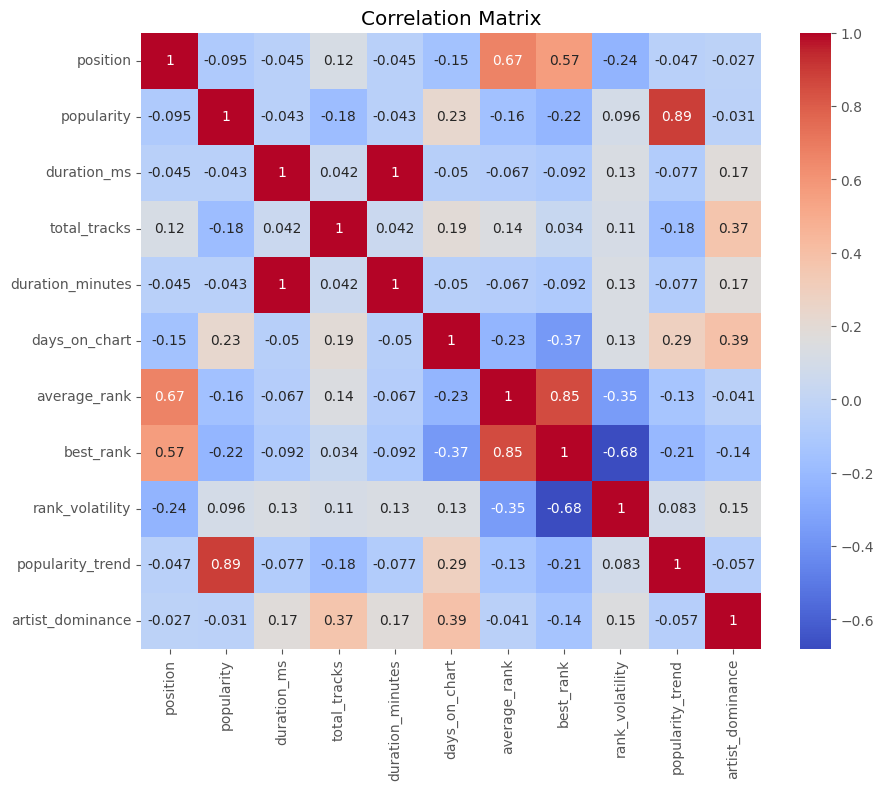

In [41]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Explicit vs Non-Explicit Songs

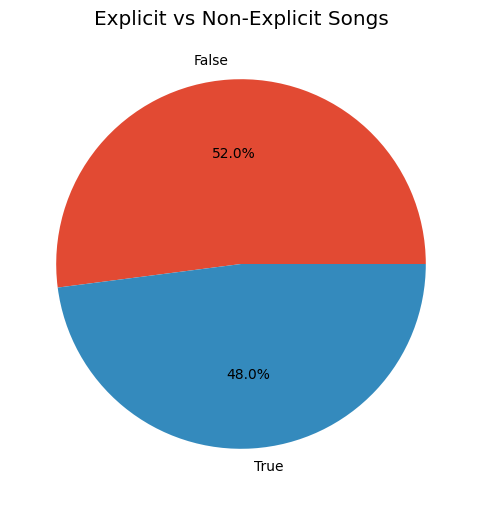

In [42]:
plt.figure(figsize=(6,6))

df["is_explicit"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Explicit vs Non-Explicit Songs")

plt.show()

# Album Type Distribution

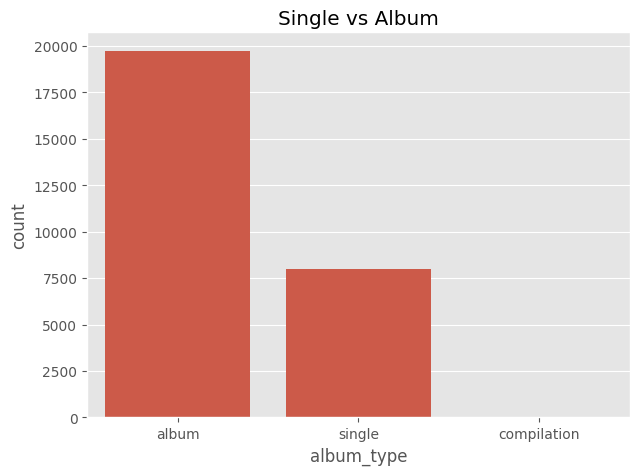

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="album_type"
)

plt.title("Single vs Album")

plt.show()

# Duration Analysis

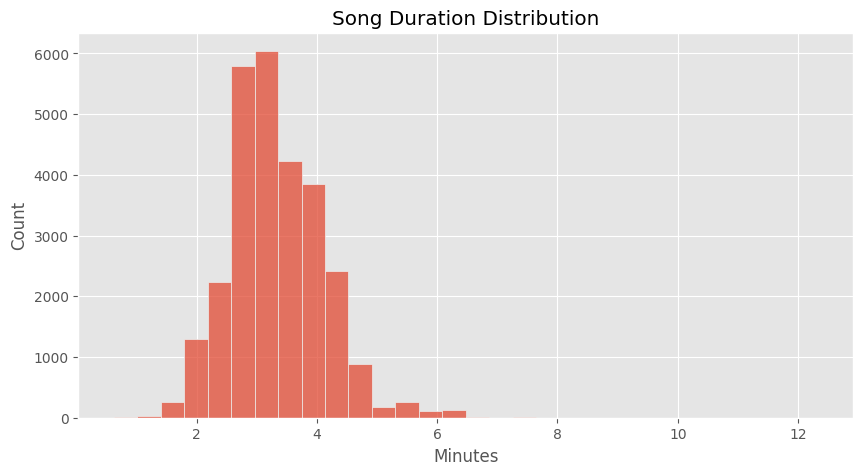

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["duration_minutes"],
    bins=30
)

plt.title("Song Duration Distribution")

plt.xlabel("Minutes")

plt.show()

# Duration vs Popularity

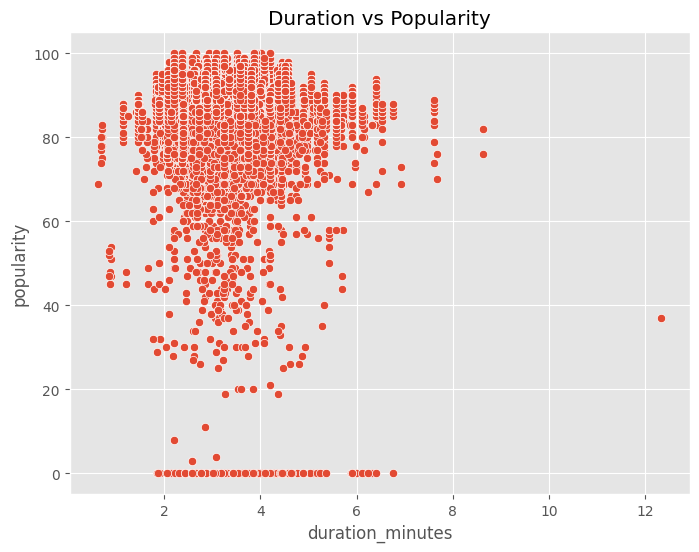

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="duration_minutes",
    y="popularity",
    data=df
)

plt.title("Duration vs Popularity")

plt.show()

# Top Artists

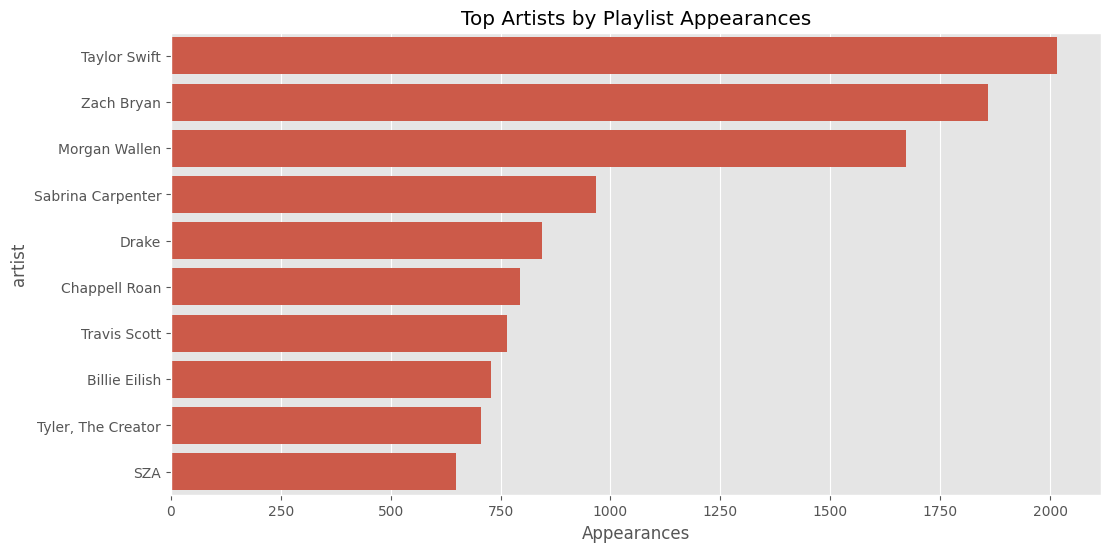

In [46]:
top_artist = (
    df.groupby("artist")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Appearances")
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Appearances",
    y="artist",
    data=top_artist
)

plt.title("Top Artists by Playlist Appearances")

plt.show()

# Artist Dominance

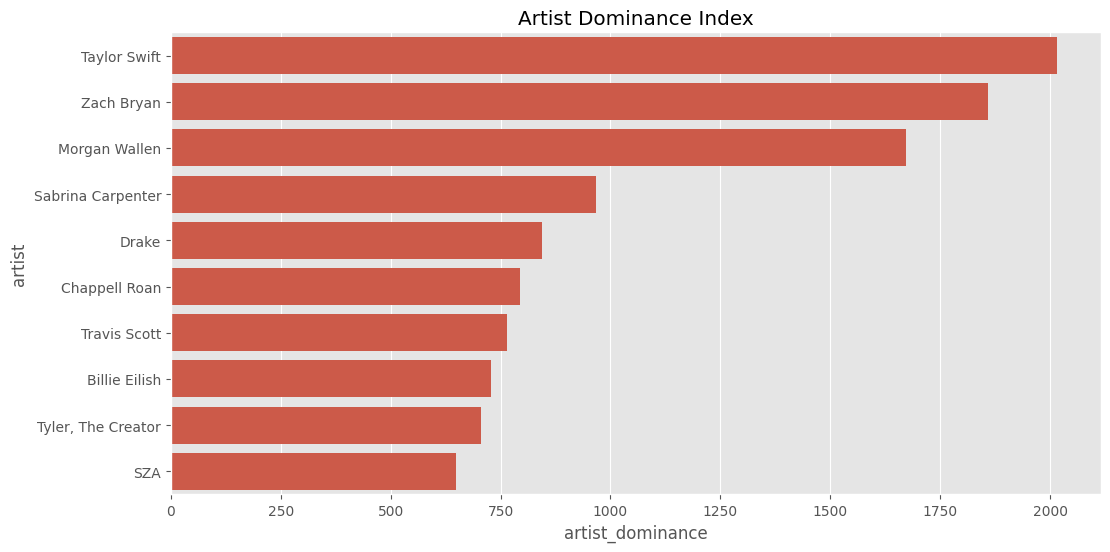

In [47]:
artist_dom = (
    df[["artist","artist_dominance"]]
      .drop_duplicates()
      .sort_values("artist_dominance",ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="artist_dominance",
    y="artist",
    data=artist_dom
)

plt.title("Artist Dominance Index")

plt.show()

# Top 10 Most Popular Songs

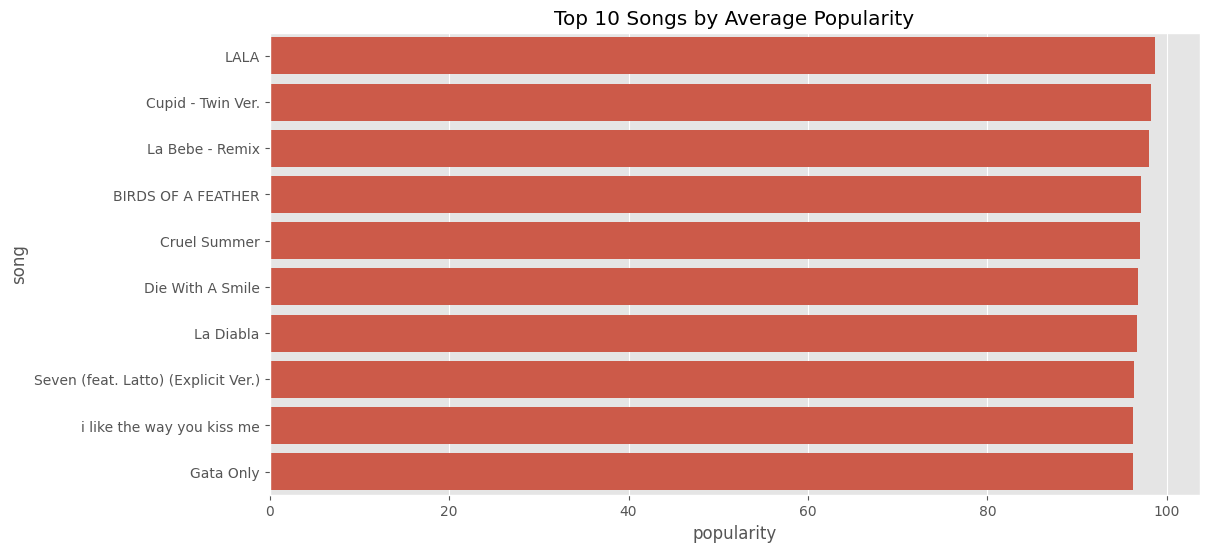

In [48]:
top_popularity = (
    df.groupby("song")["popularity"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="popularity",
    y="song",
    data=top_popularity
)

plt.title("Top 10 Songs by Average Popularity")

plt.show()

# KPI 1: Top 10 Songs by Days on Chart

In [49]:
top_days = (
    df[['song', 'artist', 'days_on_chart']]
    .drop_duplicates()
    .sort_values('days_on_chart', ascending=False)
    .head(10)
)

top_days

,song,artist,days_on_chart
20259,Something in the Orange,Zach Bryan,536
12183,Last Night,Morgan Wallen,492
9781,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,446
18869,See You Again (feat. Kali Uchis),"Tyler, The Creator",444
21033,Stick Season,Noah Kahan,414
4223,Cruel Summer,Taylor Swift,388
13105,Lose Control,Teddy Swims,329
22950,Thinkin’ Bout Me,Morgan Wallen,324
2546,Beautiful Things,Benson Boone,307
25252,You Proof,Morgan Wallen,302


# KPI 2: Top 10 Songs by Average Rank

In [51]:
top_avg_rank = (
    df[['song', 'artist', 'average_rank']]
    .drop_duplicates()
    .sort_values('average_rank')
    .head(10)
)

top_avg_rank

,song,artist,average_rank
27136,squabble up,Kendrick Lamar,1.000000
13753,MELTDOWN,Travis Scott,1.000000
6264,FE!N,Travis Scott,2.333333
26782,luther (with sza),Kendrick Lamar,2.750000
27224,tv off (feat. lefty gunplay),Kendrick Lamar,3.250000
5185,Die With A Smile,Lady Gaga & Bruno Mars,3.466019
27595,wacced out murals,Kendrick Lamar,3.500000
16372,Parade on Cleveland (feat. Drake),Young Thug,4.000000
21447,"Sticky (feat. GloRilla, Sexyy Red & Lil Wayne)","Tyler, The Creator",4.551724
22542,Taste,Sabrina Carpenter,4.625000


# KPI 3: Top 10 Highest Popularity Songs

In [52]:
top_popularity = (
    df.groupby(['song', 'artist'])['popularity']
      .mean()
      .reset_index()
      .sort_values('popularity', ascending=False)
      .head(10)
)

top_popularity

,song,artist,popularity
968,un x100to,Grupo Frontera & Bad Bunny,99.202532
411,LALA,Myke Towers,98.693878
665,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,98.654321
174,Cupid - Twin Ver.,FIFTY FIFTY,98.197183
421,La Bebe - Remix,Yng Lvcas & Peso Pluma,98.008850
191,Daylight,David Kushner,97.400000
78,BIRDS OF A FEATHER,Billie Eilish,97.157068
170,Cruel Summer,Taylor Swift,97.007732
208,Die With A Smile,Lady Gaga & Bruno Mars,96.805825
422,La Diabla,Xavi,96.695238


# KPI 4: Top Artists by Playlist Appearances

In [53]:
artist_presence = (
    df.groupby('artist')
      .size()
      .reset_index(name='appearances')
      .sort_values('appearances', ascending=False)
      .head(10)
)

artist_presence

,artist,appearances
242,Taylor Swift,2015
286,Zach Bryan,1860
177,Morgan Wallen,1672
229,Sabrina Carpenter,968
65,Drake,844
40,Chappell Roan,794
266,Travis Scott,764
22,Billie Eilish,729
273,"Tyler, The Creator",706
227,SZA,649


# KPI 5: Total Days Artist Appears

In [54]:
artist_days = (
    df.groupby('artist')['date']
      .nunique()
      .reset_index(name='days_present')
      .sort_values('days_present', ascending=False)
      .head(10)
)

artist_days

,artist,days_present
286,Zach Bryan,546
177,Morgan Wallen,540
273,"Tyler, The Creator",445
242,Taylor Swift,438
188,Noah Kahan,437
227,SZA,401
161,Luke Combs,335
22,Billie Eilish,333
266,Travis Scott,332
243,Teddy Swims,329


# KPI 6: Rank Volatility

In [55]:
stable = (
    df[['song', 'artist', 'rank_volatility']]
    .drop_duplicates()
    .sort_values('rank_volatility')
    .head(10)
)

stable

,song,artist,rank_volatility
26709,just like me,21 Savage,0.0
1571,Aquí Te Espero,Ivan Cornejo,0.0
18165,S91,KAROL G,0.0
13479,Love in This Club (feat. Young Jeezy),USHER,0.0
13098,Lonely Road (with Jelly Roll),mgk & Jelly Roll,0.0
13068,Lil Boo Thang,Paul Russell,0.0
12868,Like Crazy,Jimin,0.0
12750,Let Me Calm Down (feat. J. Cole),Nicki Minaj,0.0
691,A Night To Remember,beabadoobee & Laufey,0.0
692,ACHO PR,Bad Bunny,0.0


In [56]:
volatile = (
    df[['song', 'artist', 'rank_volatility']]
    .drop_duplicates()
    .sort_values('rank_volatility', ascending=False)
    .head(10)
)

volatile

,song,artist,rank_volatility
12866,Light Year (Practice),Lil Uzi Vert,29.698485
4611,Cruel Summer - Live from TS | The Eras Tour,Taylor Swift,25.455844
21478,Stories About My Brother,Drake,24.748737
22404,TOO FAST,Future,23.334524
1626,As Good As I Once Was,Toby Keith,22.627417
25146,Wildflower and Barley (feat. Allison Russell),Hozier,22.627417
23976,VOU 787,Bad Bunny,21.939310
21476,Stickz N Stonez,J. Cole,21.213203
18233,SKI,Future,21.213203
7516,GRACIAS POR NADA,Bad Bunny,20.784610


# KPI 7: Popularity vs Rank Correlation

In [57]:
correlation = df['popularity'].corr(df['position'])

print("Correlation:", correlation)

Correlation: -0.09452757402937853


# KPI 8: Top 10 vs Top 20 vs Top 50

In [58]:
def rank_group(rank):
    if rank <= 10:
        return "Top 10"
    elif rank <= 20:
        return "Top 20"
    else:
        return "Top 50"

df["rank_group"] = df["position"].apply(rank_group)

In [59]:
rank_summary = (
    df.groupby("rank_group")["popularity"]
      .mean()
      .reset_index()
)

rank_summary

,rank_group,popularity
0,Top 10,89.615371
1,Top 20,87.599172
2,Top 50,87.034836


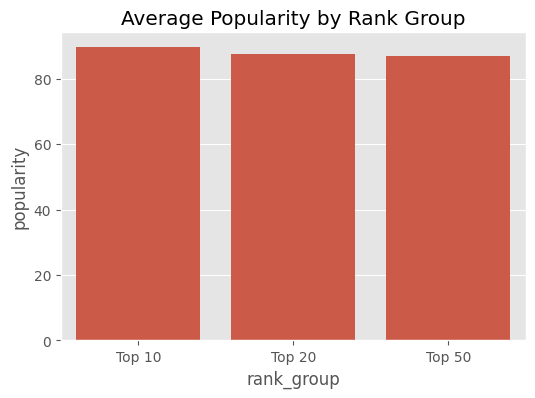

In [60]:
plt.figure(figsize=(6,4))
sns.barplot(data=rank_summary, x="rank_group", y="popularity")
plt.title("Average Popularity by Rank Group")
plt.show()

# KPI 9: Explicit vs Non-Explicit Performance

In [61]:
explicit_analysis = (
    df.groupby("is_explicit")
      .agg(
          avg_popularity=("popularity", "mean"),
          avg_rank=("position", "mean"),
          count=("song", "count")
      )
      .reset_index()
)

explicit_analysis

,is_explicit,avg_popularity,avg_rank,count
0,False,87.989143,25.59823,14461
1,True,87.310376,25.40138,13329


# KPI 10: Album Type Analysis

In [62]:
album_analysis = (
    df.groupby("album_type")
      .agg(
          avg_popularity=("popularity", "mean"),
          avg_rank=("position", "mean"),
          total_songs=("song", "count")
      )
      .reset_index()
)

album_analysis

,album_type,avg_popularity,avg_rank,total_songs
0,album,86.680263,26.105244,19735
1,compilation,78.380952,33.190476,42
2,single,90.134032,23.982279,8013


# KPI 11: Song Duration Analysis

In [63]:
duration_analysis = (
    df.groupby(pd.cut(df["duration_minutes"], bins=5))
      .agg(
          avg_popularity=("popularity", "mean"),
          avg_rank=("position", "mean")
      )
)

duration_analysis

,avg_popularity,avg_rank
duration_minutes,,
"(0.61, 2.964]",87.549948,26.381308
"(2.964, 5.307]",87.836249,24.991083
"(5.307, 7.649]",84.316271,26.502742
"(7.649, 9.991]",77.000000,29.666667
"(9.991, 12.334]",37.000000,31.000000


# KPI 12: Album Size Analysis

In [64]:
album_tracks = (
    df.groupby(pd.cut(df["total_tracks"], bins=5))
      .agg(
          avg_popularity=("popularity", "mean"),
          avg_rank=("position", "mean")
      )
)

album_tracks

,avg_popularity,avg_rank
total_tracks,,
"(0.882, 24.6]",88.025318,25.009324
"(24.6, 48.2]",83.308700,31.292797
"(48.2, 71.8]",88.666667,44.000000
"(71.8, 95.4]",NaN,NaN
"(95.4, 119.0]",92.000000,38.333333
